# GNN 分子性质预测示例（分类/回归/混合多任务）+ 不确定度（MC-Dropout/EDL）+ 可解释性（IG+SME）

本 Notebook 基于 **PyTorch Geometric (PyG)**，演示：
- **分类**：BBBP（MoleculeNet）
- **回归**：ESOL（MoleculeNet）
- **混合多任务**：把分类与回归数据合并，用 mask 处理缺失标签
- **不确定度**：MC-Dropout；EDL（分类：Dirichlet evidence；回归：NIG）
- **可解释性**：Integrated Gradients + Substructure Mask Explanation

## 环境与依赖

运行本 Notebook 主要需要以下 Python 包：

- **torch**：PyTorch 深度学习框架
- **torch-geometric**：图神经网络建模与分子图数据处理
- **numpy**：数值计算
- **rdkit**：分子解析、子结构分解与可视化
- **ipython** / **jupyter**：Notebook 显示与交互
- **scikit-learn**：部分分类指标或辅助评估
- **matplotlib**：部分可视化后端支持

In [1]:
# （可选）如果你本地还没装 PyG，请先按官方方式安装：
# https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html
# 下面这行仅用于 Notebook 环境快速安装（具体版本需与你的 torch/cuda 匹配）
# !pip install torch_geometric
import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_mean_pool
import torch_geometric.transforms as T
from torch_geometric.data import Data

print("torch:", torch.__version__)


E:\anaconda\envs\pygmol\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.10.0+cu128


In [2]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed_everything(42)
device = get_device()
device


device(type='cuda')

## 1) 数据集：BBBP（分类） & ESOL（回归）

In [3]:
import torch
import torch_geometric.transforms as T
from torch_geometric.datasets import MoleculeNet


def split_dataset(dataset, train_ratio=0.8, val_ratio=0.1, seed=42):
    n = len(dataset)                                      # 数据集中图（分子）的总数
    n_train = int(n * train_ratio)                       # 训练集样本数
    n_val = int(n * val_ratio)                           # 验证集样本数
    n_test = n - n_train - n_val                         # 测试集样本数
    g = torch.Generator().manual_seed(seed)              # 固定随机种子，保证划分可复现
    return torch.utils.data.random_split(
        dataset, [n_train, n_val, n_test], generator=g  # 按给定比例随机划分数据集
    )

def load_bbbp(root="./data"):
    ds = MoleculeNet(root=root, name="BBBP")             # BBBP：血脑屏障渗透分类数据集
    return ds, "BBBP"


def load_esol(root="./data"):
    ds = MoleculeNet(root=root, name="ESOL")             # ESOL：水溶解度回归数据集
    return ds, "ESOL"


# 加载分类数据集
ds_cls, cls_name = load_bbbp("./data")

# 加载回归数据集
ds_reg, reg_name = load_esol("./data")


print(
    "Classification dataset:", cls_name,
    "| graphs:", len(ds_cls),                # 图（分子）总数
    "| num_features:", ds_cls.num_features,  # 每个节点（原子）的特征维度，即 data.x.shape[-1]
    "| y_dim:", ds_cls[0].y.shape            # 单个样本标签张量的形状
)

print(
    "Regression dataset:", reg_name,
    "| graphs:", len(ds_reg),                # 图（分子）总数
    "| num_features:", ds_reg.num_features,  # 每个节点（原子）的特征维度
    "| y_dim:", ds_reg[0].y.shape            # 单个样本标签张量的形状
)

Classification dataset: BBBP | graphs: 2039 | num_features: 9 | y_dim: torch.Size([1, 1])
Regression dataset: ESOL | graphs: 1128 | num_features: 9 | y_dim: torch.Size([1, 1])


## 2) 通用：GIN 模型（分类/回归）+  训练/评估

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool, global_add_pool


class MLP(nn.Module):
    """两层感知机：用于分类头或回归头"""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),   # 线性映射到隐藏空间
            nn.ReLU(),                       # 非线性激活
            nn.Dropout(dropout),             # dropout 正则化
            nn.Linear(hidden_dim, out_dim),  # 输出层
        )

    def forward(self, x):
        return self.net(x)


class GINBackbone(nn.Module):
    """GIN 主干网络：输入图，输出图级 embedding"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()         # 存放多层 GINConv
        self.bns = nn.ModuleList()           # 存放每层 BatchNorm

        for i in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim),  # 第1层输入维度为 in_dim，其余层为 hidden_dim
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp))          # GINConv：邻居聚合 + MLP 更新
            self.bns.append(nn.BatchNorm1d(hidden_dim))

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)                  # 节点消息传递
            x = bn(x)                                # 批标准化
            x = F.relu(x)                            # 非线性激活
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = global_mean_pool(x, batch)               # 节点表示平均池化为图表示
        return g


class GINClassifier(nn.Module):
    """GIN 二分类模型：输出 2 维 logits"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)  # 图神经网络主干
        self.head = MLP(hidden_dim, hidden_dim, 2, dropout)              # 分类头

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)  # 图级 embedding
        return self.head(g)                                # logits [B, 2]


class GINRegressor(nn.Module):
    """GIN 回归模型：输出 1 个连续值"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)  # 图神经网络主干
        self.head = MLP(hidden_dim, hidden_dim, 1, dropout)              # 回归头

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)  # 图级 embedding
        return self.head(g).view(-1)                       # [B, 1] -> [B]


class GINMaskRegressor(nn.Module):
    """支持 pooling-mask 的回归模型：拆分为节点编码和图读出两步"""
    def __init__(self, in_dim, hidden_dim=64, num_layers=3, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.x_proj = nn.Linear(in_dim, hidden_dim)  # 输入特征先映射到 hidden_dim

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp, train_eps=True))  # train_eps=True：epsilon 参数可学习
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),   # 回归输出
        )

    def encode_nodes(self, data):
        """节点编码阶段：输出每个节点的 embedding"""
        x = data.x.float()
        h = self.x_proj(x)

        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, data.edge_index)               # 节点消息传递
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)

        return h                                      # [N, hidden_dim]

    def readout(self, h, batch, node_keep_mask=None):
        """图读出阶段：支持在 pooling 时屏蔽部分节点"""
        if node_keep_mask is not None:
            h = h * node_keep_mask.view(-1, 1).to(h.dtype)  # 被屏蔽节点贡献置零

        g = global_add_pool(h, batch)                 # 节点表示求和为图表示
        out = self.head(g).view(-1)                   # 图级回归输出
        return out

    def forward(self, data, node_keep_mask=None):
        if not hasattr(data, "batch") or data.batch is None:
            data.batch = torch.zeros(
                data.num_nodes,
                dtype=torch.long,
                device=data.x.device
            )                                         # 单图时手动补 batch

        h = self.encode_nodes(data)                   # 节点编码
        out = self.readout(h, data.batch, node_keep_mask=node_keep_mask)  # 图读出
        return out


@torch.no_grad()
def eval_classification(model, loader, device):
    """分类评估：返回 accuracy"""
    model.eval()
    correct, total = 0, 0

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)                         # 分类 logits
        pred = logits.argmax(dim=-1)                  # 预测类别
        y = batch.y.view(-1).long()                   # 真实标签
        correct += int((pred == y).sum())
        total += y.numel()

    return correct / max(total, 1)


@torch.no_grad()
def eval_regression(model, loader, device):
    """回归评估：返回 RMSE 和 MAE"""
    model.eval()
    ys, ps = [], []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)                           # 预测值
        y = batch.y.view(-1).float()                  # 真实值
        ys.append(y.detach().cpu())
        ps.append(pred.detach().cpu())

    y = torch.cat(ys)
    p = torch.cat(ps)

    rmse = torch.sqrt(torch.mean((p - y) ** 2)).item()   # 均方根误差
    mae = torch.mean(torch.abs(p - y)).item()            # 平均绝对误差
    return rmse, mae


def train_one_epoch_classification(model, loader, opt, device):
    """分类任务训练一个 epoch：返回平均交叉熵损失"""
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)                         # 前向传播
        y = batch.y.view(-1).long()                  # 真实标签
        loss = F.cross_entropy(logits, y)            # 交叉熵损失

        opt.zero_grad()
        loss.backward()                              # 反向传播
        opt.step()

        total_loss += float(loss) * y.size(0)        # 按样本数累计损失

    return total_loss / max(len(loader.dataset), 1)


def train_one_epoch_regression(model, loader, opt, device):
    """回归任务训练一个 epoch：返回平均 MSE 损失"""
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)                          # 前向传播
        y = batch.y.view(-1).float()                 # 真实值
        loss = F.mse_loss(pred, y)                   # 均方误差损失

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += float(loss) * y.size(0)        # 按样本数累计损失

    return total_loss / max(len(loader.dataset), 1)

## 3) 任务A：BBBP 分类训练

In [5]:
# =========================
# 1. 数据集划分与加载
# =========================
train_set, val_set, test_set = split_dataset(ds_cls, seed=42)      # 按固定随机种子划分 train / val / test

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)  # 训练集：小批量加载，并在每轮打乱
val_loader   = DataLoader(val_set, batch_size=256)                 # 验证集：只做前向评估
test_loader  = DataLoader(test_set, batch_size=256)                # 测试集：只做最终评估


# =========================
# 2. 模型构建
# =========================
model_cls = GINClassifier(                                          # 构建 GIN 二分类模型
    in_dim=ds_cls.num_features,                                     # 节点输入特征维度
    hidden_dim=128,                                                 # 隐藏层维度
    num_layers=4,                                                   # GINConv 层数
    dropout=0.2                                                     # dropout 概率
).to(device)


# =========================
# 3. 优化器设置
# =========================
opt = torch.optim.Adam(                                             # Adam 优化器
    model_cls.parameters(),
    lr=1e-3,                                                        # 学习率
    weight_decay=1e-5                                               # L2 正则
)


# =========================
# 4. 训练过程
# =========================
best_val, best_state = 0.0, None                                    # 记录最佳验证集准确率及对应参数

for epoch in range(1, 101):                                          # 训练 100 个 epoch
    loss = train_one_epoch_classification(                          # 训练一个 epoch，返回平均训练损失
        model_cls, train_loader, opt, device
    )
    val_acc = eval_classification(                                  # 在验证集上计算 accuracy
        model_cls, val_loader, device
    )

    if val_acc > best_val:                                          # 若当前验证性能更好，则保存参数
        best_val = val_acc
        best_state = {
            k: v.detach().cpu() for k, v in model_cls.state_dict().items()
        }

    if epoch % 10 == 0:                                              # 每 10 轮打印一次训练信息
        print(f"Epoch {epoch:03d} | loss={loss:.4f} | val_acc={val_acc:.4f}")


# =========================
# 5. 恢复最佳模型
# =========================
if best_state is not None:
    model_cls.load_state_dict(best_state)                           # 恢复验证集表现最好的模型参数


# =========================
# 6. 测试集评估
# =========================
test_acc = eval_classification(model_cls, test_loader, device)      # 在测试集上评估最终性能

print("Best val_acc =", best_val)
print("Test acc     =", test_acc)

C:\Users\A\AppData\Local\Temp\ipykernel_48388\3861938223.py:188: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  total_loss += float(loss) * y.size(0)        # 按样本数累计损失


Epoch 010 | loss=0.3485 | val_acc=0.8424
Epoch 020 | loss=0.2893 | val_acc=0.8325
Epoch 030 | loss=0.2637 | val_acc=0.8177
Epoch 040 | loss=0.2450 | val_acc=0.8522
Epoch 050 | loss=0.2243 | val_acc=0.8177
Epoch 060 | loss=0.2122 | val_acc=0.8621
Epoch 070 | loss=0.1979 | val_acc=0.7980
Epoch 080 | loss=0.1623 | val_acc=0.8522
Epoch 090 | loss=0.1673 | val_acc=0.8030
Epoch 100 | loss=0.1536 | val_acc=0.8522
Best val_acc = 0.8916256157635468
Test acc     = 0.8682926829268293


## 4) 任务B：ESOL 回归训练

In [6]:
# =========================
# 1. 数据集划分与加载
# =========================
train_set, val_set, test_set = split_dataset(ds_reg, seed=42)      # 按固定随机种子划分 train / val / test

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)  # 训练集：小批量加载，并在每轮打乱
val_loader   = DataLoader(val_set, batch_size=256)                 # 验证集：只做前向评估
test_loader  = DataLoader(test_set, batch_size=256)                # 测试集：只做最终评估


# =========================
# 2. 模型构建
# =========================
model_reg = GINRegressor(                                           # 构建 GIN 回归模型
    in_dim=ds_reg.num_features,                                     # 节点输入特征维度
    hidden_dim=128,                                                 # 隐藏层维度
    num_layers=4,                                                   # GINConv 层数
    dropout=0.2                                                     # dropout 概率
).to(device)


# =========================
# 3. 优化器设置
# =========================
opt = torch.optim.Adam(                                             # Adam 优化器
    model_reg.parameters(),
    lr=1e-3,                                                        # 学习率
    weight_decay=1e-5                                               # L2 正则
)


# =========================
# 4. 训练过程
# =========================
best_val, best_state = 1e9, None                                    # 记录最优验证集 RMSE 及对应参数

for epoch in range(1, 101):                                         # 训练 100 个 epoch
    loss = train_one_epoch_regression(                              # 训练一个 epoch，返回平均训练损失
        model_reg, train_loader, opt, device
    )
    val_rmse, val_mae = eval_regression(                            # 在验证集上评估 RMSE 和 MAE
        model_reg, val_loader, device
    )

    if val_rmse < best_val:                                         # 若当前验证 RMSE 更小，则保存参数
        best_val = val_rmse
        best_state = {
            k: v.detach().cpu() for k, v in model_reg.state_dict().items()
        }

    if epoch % 10 == 0:                                             # 每 10 轮打印一次训练信息
        print(f"Epoch {epoch:03d} | loss={loss:.4f} | val_rmse={val_rmse:.4f} | val_mae={val_mae:.4f}")


# =========================
# 5. 恢复最佳模型
# =========================
if best_state is not None:
    model_reg.load_state_dict(best_state)                           # 恢复验证集表现最好的模型参数


# =========================
# 6. 测试集评估
# =========================
test_rmse, test_mae = eval_regression(model_reg, test_loader, device)  # 在测试集上评估最终性能

print("Best val_rmse =", best_val)
print("Test rmse/mae =", test_rmse, test_mae)

Epoch 010 | loss=1.2200 | val_rmse=1.1454 | val_mae=0.8662
Epoch 020 | loss=1.3627 | val_rmse=2.3486 | val_mae=1.8686
Epoch 030 | loss=1.0934 | val_rmse=1.2235 | val_mae=0.9292
Epoch 040 | loss=0.8806 | val_rmse=1.8579 | val_mae=1.4320
Epoch 050 | loss=0.9426 | val_rmse=1.7869 | val_mae=1.3501
Epoch 060 | loss=0.7569 | val_rmse=1.7441 | val_mae=1.3608
Epoch 070 | loss=0.6696 | val_rmse=1.2164 | val_mae=0.9417
Epoch 080 | loss=0.7611 | val_rmse=0.9433 | val_mae=0.7071
Epoch 090 | loss=0.9308 | val_rmse=0.8917 | val_mae=0.6719
Epoch 100 | loss=0.6216 | val_rmse=0.8323 | val_mae=0.6342
Best val_rmse = 0.7946901321411133
Test rmse/mae = 0.6118793487548828 0.4898923337459564


## 5) 任务C：混合多任务（分类+回归）

In [124]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader


class MixedMolDataset(torch.utils.data.Dataset):
    """混合数据集：把分类集和回归集合并为一个统一数据集"""
    def __init__(self, ds_cls, ds_reg):
        super().__init__()
        self.ds_cls = ds_cls                         # 分类数据集
        self.ds_reg = ds_reg                         # 回归数据集
        self.n_cls = len(ds_cls)                    # 分类样本数
        self.n_reg = len(ds_reg)                    # 回归样本数

    def __len__(self):
        return self.n_cls + self.n_reg              # 混合数据集总长度

    def __getitem__(self, idx):
        if idx < self.n_cls:
            d = self.ds_cls[idx]                    # 取分类样本
            d.y_cls = d.y.view(-1).long()           # 分类标签
            d.y_reg = torch.tensor([0.0])           # 回归标签占位
            d.mask_cls = torch.tensor([1.0])        # 该样本参与分类损失
            d.mask_reg = torch.tensor([0.0])        # 该样本不参与回归损失
        else:
            d = self.ds_reg[idx - self.n_cls]       # 取回归样本
            d.y_cls = torch.tensor([0]).long()      # 分类标签占位
            d.y_reg = d.y.view(-1).float()          # 回归标签
            d.mask_cls = torch.tensor([0.0])        # 该样本不参与分类损失
            d.mask_reg = torch.tensor([1.0])        # 该样本参与回归损失

        return d


class GINMultiTask(nn.Module):
    """多任务 GIN：共享主干 + 分类头 + 回归头"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)  # 共享 GIN 主干
        self.head_cls = MLP(hidden_dim, hidden_dim, 2, dropout)          # 分类头：输出 2 维 logits
        self.head_reg = MLP(hidden_dim, hidden_dim, 1, dropout)          # 回归头：输出 1 个连续值

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)  # 得到图级 embedding
        logits_cls = self.head_cls(g)                      # 分类输出 [B, 2]
        pred_reg = self.head_reg(g).view(-1)               # 回归输出 [B]
        return logits_cls, pred_reg


# =========================
# 1. 构建混合数据集
# =========================
mixed = MixedMolDataset(ds_cls, ds_reg)                    # 合并分类集与回归集

n = len(mixed)                                             # 混合数据集总样本数
n_train = int(0.8 * n)                                     # 训练集样本数
n_val = int(0.1 * n)                                       # 验证集样本数
n_test = n - n_train - n_val                               # 测试集样本数

train_set, val_set, test_set = torch.utils.data.random_split(
    mixed,
    [n_train, n_val, n_test],                              # 按比例划分 train / val / test
    generator=torch.Generator().manual_seed(42)            # 固定随机种子，保证划分可复现
)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)   # 训练集：小批量加载并打乱
val_loader   = DataLoader(val_set, batch_size=256)                  # 验证集：只做前向评估
test_loader  = DataLoader(test_set, batch_size=256)                 # 测试集：只做最终评估


# =========================
# 2. 模型构建与优化器
# =========================
model_mt = GINMultiTask(
    in_dim=ds_cls.num_features                               # 输入特征维度（分类集与回归集一致）
).to(device)

opt = torch.optim.Adam(
    model_mt.parameters(),                                   # 优化模型全部参数
    lr=1e-3,                                                 # 学习率
    weight_decay=1e-5                                        # L2 正则
)


# =========================
# 3. 评估函数
# =========================
@torch.no_grad()
def eval_mixed(model, loader, device):
    model.eval()

    correct = 0                                              # 分类正确样本数
    total = 0                                                # 分类总样本数
    ys, ps = [], []                                          # 保存回归真实值与预测值

    for batch in loader:
        batch = batch.to(device)
        logits, pred_reg = model(batch)                      # 同时得到分类输出和回归输出

        # ---- 分类部分 ----
        sel_cls = batch.mask_cls.view(-1) > 0.5              # 选择分类样本
        if int(sel_cls.sum()) > 0:
            y_cls = batch.y_cls.view(-1)                     # 分类真实标签
            pred_cls = logits.argmax(dim=-1)                 # 分类预测标签
            correct += int((pred_cls[sel_cls] == y_cls[sel_cls]).sum())
            total += int(sel_cls.sum())

        # ---- 回归部分 ----
        sel_reg = batch.mask_reg.view(-1) > 0.5              # 选择回归样本
        if int(sel_reg.sum()) > 0:
            y_reg = batch.y_reg.view(-1)                     # 回归真实值
            ys.append(y_reg[sel_reg].detach().cpu())
            ps.append(pred_reg[sel_reg].detach().cpu())

    acc = correct / max(total, 1)                            # 分类准确率

    rmse = float("nan")                                      # 默认回归 RMSE 为 nan
    if len(ys) > 0:
        y = torch.cat(ys)
        p = torch.cat(ps)
        rmse = torch.sqrt(torch.mean((p - y) ** 2)).item()   # 回归 RMSE

    return acc, rmse


# =========================
# 4. 训练过程
# =========================
for epoch in range(1, 101):                                  # 训练 100 个 epoch
    model_mt.train()
    total_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)
        logits, pred_reg = model_mt(batch)                   # 前向传播：分类输出 + 回归输出

        loss = 0.0                                           # 总损失 = 分类损失 + 回归损失

        # ---- 分类损失 ----
        sel_cls = batch.mask_cls.view(-1) > 0.5              # 选择分类样本
        if int(sel_cls.sum()) > 0:
            y_cls = batch.y_cls.view(-1)
            loss = loss + F.cross_entropy(                   # 只在分类样本上计算交叉熵
                logits[sel_cls], y_cls[sel_cls]
            )

        # ---- 回归损失 ----
        sel_reg = batch.mask_reg.view(-1) > 0.5              # 选择回归样本
        if int(sel_reg.sum()) > 0:
            y_reg = batch.y_reg.view(-1)
            loss = loss + F.mse_loss(                        # 只在回归样本上计算 MSE
                pred_reg[sel_reg], y_reg[sel_reg]
            )

        opt.zero_grad()
        loss.backward()                                      # 反向传播
        opt.step()                                           # 更新参数

        total_loss += float(loss) * batch.num_graphs         # 按图数累计总损失

    if epoch % 10 == 0:                                       # 每 10 轮打印一次验证结果
        val_acc, val_rmse = eval_mixed(model_mt, val_loader, device)
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={total_loss/len(train_loader.dataset):.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_rmse={val_rmse:.4f}"
        )


# =========================
# 5. 测试集评估
# =========================
test_acc, test_rmse = eval_mixed(model_mt, test_loader, device)     # 在测试集上评估最终性能
print("Test acc/rmse =", test_acc, test_rmse)

Epoch 010 | train_loss=1.5062 | val_acc=0.8762 | val_rmse=1.4560
Epoch 020 | train_loss=1.2572 | val_acc=0.8238 | val_rmse=1.1360
Epoch 030 | train_loss=1.1832 | val_acc=0.8667 | val_rmse=0.8373
Epoch 040 | train_loss=0.9674 | val_acc=0.8667 | val_rmse=1.0175
Epoch 050 | train_loss=0.9373 | val_acc=0.8857 | val_rmse=1.3556
Epoch 060 | train_loss=0.8202 | val_acc=0.8333 | val_rmse=0.8788
Epoch 070 | train_loss=0.7635 | val_acc=0.9095 | val_rmse=0.6643
Epoch 080 | train_loss=0.7529 | val_acc=0.8857 | val_rmse=1.6459
Epoch 090 | train_loss=0.7316 | val_acc=0.8952 | val_rmse=0.8819
Epoch 100 | train_loss=0.6475 | val_acc=0.8952 | val_rmse=0.7813
Test acc/rmse = 0.8673469387755102 0.767737627029419


## 6) 不确定度A：MC-Dropout（分类/回归）

In [7]:
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader


# =========================
# 1. MC-Dropout：分类任务预测
# =========================
@torch.no_grad()
def mc_dropout_predict_classification(model, data, T=30):
    """
    输入：
      - model: 输出 [B, 2] logits 的分类模型
      - data : 一个 batch 图数据
      - T    : MC 采样次数

    输出：
      - mean_prob: [B, 2]，平均预测概率
      - var_prob : [B, 2]，预测概率方差
    """
    model.train()                                         # 关键：保持 dropout 打开
    probs = []

    for _ in range(T):
        logits = model(data)                              # 前向传播，得到 logits [B, 2]
        probs.append(
            F.softmax(logits, dim=-1).unsqueeze(0)        # 转成概率，并补一个采样维度 [1, B, 2]
        )

    probs = torch.cat(probs, dim=0)                       # 拼成 [T, B, 2]
    return probs.mean(dim=0), probs.var(dim=0, unbiased=False)


# =========================
# 2. MC-Dropout：回归任务预测
# =========================
@torch.no_grad()
def mc_dropout_predict_regression(model, data, T=30):
    """
    输入：
      - model: 输出 [B] 的回归模型
      - data : 一个 batch 图数据
      - T    : MC 采样次数

    输出：
      - mean: [B]，平均预测值
      - var : [B]，预测方差
    """
    model.train()                                         # 关键：保持 dropout 打开
    preds = []

    for _ in range(T):
        preds.append(model(data).unsqueeze(0))            # 每次采样结果形状为 [1, B]

    preds = torch.cat(preds, dim=0)                       # 拼成 [T, B]
    return preds.mean(dim=0), preds.var(dim=0, unbiased=False)


# =========================
# 3. 分类任务：按 MC 不确定度分组
# =========================
cls_means = []                                            # 保存平均预测概率
cls_vars  = []                                            # 保存每个样本的不确定度
cls_trues = []                                            # 保存真实标签

for batch in DataLoader(ds_cls, batch_size=64, shuffle=False):
    batch = batch.to(device)

    mean_prob, var_prob = mc_dropout_predict_classification(
        model_cls, batch, T=50                            # 对每个 batch 做 50 次 dropout 采样
    )

    unc = var_prob.sum(dim=-1).detach().cpu().numpy()     # 每个样本的分类不确定度，可理解为两个类别概率方差之和

    cls_means.append(mean_prob.detach().cpu().numpy())    # 平均预测概率
    cls_vars.append(unc)                                  # 不确定度
    cls_trues.append(batch.y.view(-1).cpu().numpy())      # 真实标签

# 拼接所有 batch 的结果
cls_means = np.concatenate(cls_means, axis=0)             # [N, 2]
cls_vars  = np.concatenate(cls_vars, axis=0)              # [N]
cls_trues = np.concatenate(cls_trues, axis=0)             # [N]

# 按不确定度从小到大排序
cls_sorted_idx = np.argsort(cls_vars)
n_cls = len(cls_sorted_idx)
cls_group_size = n_cls // 5                               # 分成 5 组

print("=== Classification: 5 groups by uncertainty ===")
for i in range(5):
    start = i * cls_group_size
    end   = n_cls if i == 4 else (i + 1) * cls_group_size
    idxs = cls_sorted_idx[start:end]                      # 当前不确定度分组的样本索引

    preds = cls_means[idxs].argmax(axis=-1)               # 取平均概率最大者作为预测类别
    trues = cls_trues[idxs]
    acc   = (preds == trues).mean()                       # 当前组准确率

    print(
        f"Group {i+1:02d} | "
        f"unc range [{cls_vars[idxs].min():.4f}, {cls_vars[idxs].max():.4f}] | "
        f"size={len(idxs)} | "
        f"acc={acc:.4f}"
    )


# =========================
# 4. 回归任务：按 MC 不确定度分组
# =========================
reg_means = []                                            # 保存平均预测值
reg_vars  = []                                            # 保存每个样本的不确定度
reg_trues = []                                            # 保存真实值

for batch in DataLoader(ds_reg, batch_size=64, shuffle=False):
    batch = batch.to(device)

    mean_pred, var_pred = mc_dropout_predict_regression(
        model_reg, batch, T=50                            # 对每个 batch 做 50 次 dropout 采样
    )

    unc = var_pred.detach().cpu().numpy()                 # 每个样本的回归不确定度

    reg_means.append(mean_pred.detach().cpu().numpy())    # 平均预测值
    reg_vars.append(unc)                                  # 预测方差
    reg_trues.append(batch.y.view(-1).cpu().numpy())      # 真实值

# 拼接所有 batch 的结果
reg_means = np.concatenate(reg_means, axis=0)             # [N]
reg_vars  = np.concatenate(reg_vars, axis=0)              # [N]
reg_trues = np.concatenate(reg_trues, axis=0)             # [N]

# 按不确定度从小到大排序
reg_sorted_idx = np.argsort(reg_vars)
n_reg = len(reg_sorted_idx)
reg_group_size = n_reg // 5                               # 分成 5 组

print("\n=== Regression: 5 groups by uncertainty ===")
for i in range(5):
    start = i * reg_group_size
    end   = n_reg if i == 4 else (i + 1) * reg_group_size
    idxs = reg_sorted_idx[start:end]                      # 当前不确定度分组的样本索引

    preds = reg_means[idxs]
    trues = reg_trues[idxs]

    rmse = np.sqrt(((preds - trues) ** 2).mean())         # 当前组 RMSE
    mae  = np.abs(preds - trues).mean()                   # 当前组 MAE

    print(
        f"Group {i+1:02d} | "
        f"unc range [{reg_vars[idxs].min():.6f}, {reg_vars[idxs].max():.6f}] | "
        f"size={len(idxs)} | "
        f"rmse={rmse:.4f} | "
        f"mae={mae:.4f}"
    )

=== Classification: 5 groups by uncertainty ===
Group 01 | unc range [0.0000, 0.0000] | size=407 | acc=0.9607
Group 02 | unc range [0.0000, 0.0024] | size=407 | acc=0.9410
Group 03 | unc range [0.0024, 0.0200] | size=407 | acc=0.8428
Group 04 | unc range [0.0200, 0.0546] | size=407 | acc=0.7027
Group 05 | unc range [0.0551, 0.3370] | size=411 | acc=0.6350

=== Regression: 5 groups by uncertainty ===
Group 01 | unc range [0.009745, 0.046129] | size=225 | rmse=0.5460 | mae=0.4127
Group 02 | unc range [0.046181, 0.073642] | size=225 | rmse=0.7017 | mae=0.5099
Group 03 | unc range [0.073681, 0.109506] | size=225 | rmse=0.6668 | mae=0.5370
Group 04 | unc range [0.109981, 0.160178] | size=225 | rmse=0.7800 | mae=0.6033
Group 05 | unc range [0.160685, 0.554021] | size=228 | rmse=1.0579 | mae=0.8500


## 7) 不确定度B：EDL 分类（Dirichlet evidence）

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader


# =========================
# 1. Dirichlet KL 散度
# =========================
def dirichlet_kl(alpha, prior=None):
    """
    计算 Dirichlet(alpha) 与先验 Dirichlet(prior) 的 KL 散度
    默认先验为均匀 Dirichlet，即 prior = 1
    """
    if prior is None:
        prior = torch.ones_like(alpha)                            # 默认均匀先验

    sum_alpha = alpha.sum(dim=-1, keepdim=True)                  # S = sum(alpha)
    sum_prior = prior.sum(dim=-1, keepdim=True)                  # S0 = sum(prior)

    lnB_alpha = torch.lgamma(sum_alpha) - torch.lgamma(alpha).sum(dim=-1, keepdim=True)  # log B(alpha)
    lnB_prior = torch.lgamma(sum_prior) - torch.lgamma(prior).sum(dim=-1, keepdim=True)  # log B(prior)

    digamma_sum = torch.digamma(sum_alpha)                       # digamma(S)
    digamma_alpha = torch.digamma(alpha)                         # digamma(alpha_k)

    kl = (alpha - prior) * (digamma_alpha - digamma_sum)        # KL 中的主项
    kl = kl.sum(dim=-1, keepdim=True) + lnB_alpha - lnB_prior   # 完整 KL
    return kl.squeeze(-1)


# =========================
# 2. EDL 分类拟合损失
# =========================
def edl_ce_loss(alpha, y_onehot):
    """
    EDL 分类损失中的拟合项：
    用 Dirichlet 分布的期望对数概率来替代普通交叉熵
    """
    S = alpha.sum(dim=-1, keepdim=True)                          # S = sum(alpha)
    E_log_p = torch.digamma(alpha) - torch.digamma(S)           # E[log p]
    return -(y_onehot * E_log_p).sum(dim=-1)                    # 对真实类别取负对数似然


# =========================
# 3. EDL-Dirichlet 分类模型
# =========================
class GINDirichletClassifier(nn.Module):
    """GIN + Dirichlet 分类头：输出 Dirichlet 参数 alpha"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2, num_classes=2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)   # 共享 GIN 主干
        self.evidence_head = MLP(hidden_dim, hidden_dim, num_classes, dropout)  # 输出 evidence

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)        # 图级 embedding
        evidence = F.softplus(self.evidence_head(g))             # evidence >= 0
        alpha = evidence + 1.0                                   # Dirichlet 参数 alpha > 1
        return alpha


# =========================
# 4. EDL 训练函数
# =========================
def train_edl_dirichlet(model, loader, opt, device, epoch, anneal_epochs=10, kl_scale=1e-2):
    """
    训练一个 epoch：
      总损失 = 拟合损失 + KL 正则
    其中 KL 正则采用逐步退火（annealing）方式引入
    """
    model.train()
    total = 0.0

    for batch in loader:
        batch = batch.to(device)
        y = batch.y.view(-1).long()                              # 真实标签
        y_onehot = F.one_hot(y, num_classes=2).float()          # one-hot 标签

        alpha = model(batch)                                     # 预测 Dirichlet 参数
        loss_fit = edl_ce_loss(alpha, y_onehot).mean()          # 拟合项
        kl = dirichlet_kl(alpha).mean()                         # KL 正则项

        w = min(1.0, epoch / float(anneal_epochs))              # KL 退火系数：前几轮逐步增大
        loss = loss_fit + w * kl_scale * kl                     # 总损失

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += float(loss) * batch.num_graphs                 # 按图数累计损失

    return total / max(len(loader.dataset), 1)


# =========================
# 5. EDL 预测函数
# =========================
@torch.no_grad()
def edl_predict_dirichlet(model, data):
    """
    输入：
      - model: 输出 alpha 的 Dirichlet 分类模型
      - data : 一个 batch 图数据

    输出：
      - p_mean: [B, K]，Dirichlet 均值，即类别概率均值
      - u     : [B]，总不确定度，值越大表示越不确定
    """
    model.eval()
    alpha = model(data)                                          # Dirichlet 参数 alpha
    S = alpha.sum(dim=-1, keepdim=True)                          # S = sum(alpha)
    p_mean = alpha / S                                           # Dirichlet 均值
    u = (alpha.size(-1) / S).squeeze(-1)                         # 总不确定度 u = K / S
    return p_mean, u


# =========================
# 6. 数据集划分与加载
# =========================
train_set, val_set, test_set = split_dataset(ds_cls, seed=42)    # 按固定随机种子划分 train / val / test

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)  # 训练集：小批量加载并打乱
val_loader   = DataLoader(val_set, batch_size=256)                 # 验证集：只做前向评估
test_loader  = DataLoader(test_set, batch_size=256)                # 测试集：只做最终评估


# =========================
# 7. 模型构建与优化器
# =========================
edl_cls = GINDirichletClassifier(                                  # 构建 EDL Dirichlet 分类模型
    in_dim=ds_cls.num_features,
    dropout=0.2
).to(device)

opt = torch.optim.Adam(
    edl_cls.parameters(),
    lr=1e-3,                                                       # 学习率
    weight_decay=1e-5                                              # L2 正则
)


# =========================
# 8. 训练过程
# =========================
for epoch in range(1, 31):                                         # 训练 30 个 epoch
    loss = train_edl_dirichlet(
        edl_cls, train_loader, opt, device, epoch
    )

    if epoch % 5 == 0:                                             # 每 5 轮在验证集上评估一次
        correct = 0
        total = 0

        for batch in val_loader:
            batch = batch.to(device)
            p_mean, u = edl_predict_dirichlet(edl_cls, batch)      # p_mean: 平均类别概率, u: 不确定度
            pred = p_mean.argmax(dim=-1)                           # 取最大概率类别作为预测
            y = batch.y.view(-1).long()
            correct += int((pred == y).sum())
            total += y.numel()

        print(f"Epoch {epoch:03d} | loss={loss:.4f} | val_acc={correct/max(total,1):.4f}")


# =========================
# 9. 单个 batch 的预测示例
# =========================
batch = next(iter(test_loader)).to(device)                         # 取测试集中的一个 batch
p_mean, u = edl_predict_dirichlet(edl_cls, batch)

print(
    "EDL cls sample[0] p_mean:",
    p_mean[0].detach().cpu().numpy(),                              # 第一个样本的预测概率均值
    "uncertainty u:",
    float(u[0])                                                    # 第一个样本的不确定度
)


# =========================
# 10. 在测试集上统计 EDL 预测结果与不确定度
# =========================
edl_means = []                                                     # 保存预测类别
edl_uncs  = []                                                     # 保存不确定度
edl_trues = []                                                     # 保存真实标签

for batch in test_loader:
    batch = batch.to(device)

    p_mean, u = edl_predict_dirichlet(edl_cls, batch)              # p_mean: [B, K], u: [B]

    preds = p_mean.argmax(dim=-1).detach().cpu().numpy()           # 预测类别
    truths = batch.y.view(-1).cpu().numpy()                        # 真实标签

    edl_means.append(preds)
    edl_uncs.append(u.detach().cpu().numpy())
    edl_trues.append(truths)

# 拼接所有测试样本
edl_means = np.concatenate(edl_means, axis=0)                      # [N_test]
edl_uncs  = np.concatenate(edl_uncs, axis=0)                       # [N_test]
edl_trues = np.concatenate(edl_trues, axis=0)                      # [N_test]


# =========================
# 11. 按不确定度从小到大排序，并分成 5 组
# =========================
sorted_idx = np.argsort(edl_uncs)                                  # 升序：最确定 -> 最不确定
N = len(sorted_idx)
group_size = N // 5                                                # 五等分

print("=== EDL Dirichlet Classification by Uncertainty Quintiles ===")
for i in range(5):
    start = i * group_size
    end   = N if i == 4 else (i + 1) * group_size
    idxs = sorted_idx[start:end]                                   # 当前组样本索引

    group_unc_min = edl_uncs[idxs].min()                           # 当前组最小不确定度
    group_unc_max = edl_uncs[idxs].max()                           # 当前组最大不确定度
    group_size_i  = len(idxs)                                      # 当前组样本数
    avg_unc = edl_uncs[idxs].mean()                                # 当前组平均不确定度

    preds = edl_means[idxs]                                        # 当前组预测标签
    trues = edl_trues[idxs]                                        # 当前组真实标签
    acc   = (preds == trues).mean()                                # 当前组准确率

    print(
        f"Group {i+1:02d} | "
        f"unc range [{group_unc_min:.4f}, {group_unc_max:.4f}] | "
        f"avg_unc={avg_unc:.4f} | "
        f"size={group_size_i} | "
        f"acc={acc:.4f}"
    )

Epoch 005 | loss=0.4251 | val_acc=0.7586
Epoch 010 | loss=0.3790 | val_acc=0.7931
Epoch 015 | loss=0.3494 | val_acc=0.8670
Epoch 020 | loss=0.3324 | val_acc=0.8276
Epoch 025 | loss=0.3345 | val_acc=0.8128
Epoch 030 | loss=0.3134 | val_acc=0.7931
EDL cls sample[0] p_mean: [0.11728562 0.8827144 ] uncertainty u: 0.05492999777197838
=== EDL Dirichlet Classification by Uncertainty Quintiles ===
Group 01 | unc range [0.0121, 0.0451] | avg_unc=0.0358 | size=41 | acc=0.8049
Group 02 | unc range [0.0452, 0.0539] | avg_unc=0.0499 | size=41 | acc=0.7805
Group 03 | unc range [0.0540, 0.0628] | avg_unc=0.0580 | size=41 | acc=0.8780
Group 04 | unc range [0.0629, 0.0732] | avg_unc=0.0677 | size=41 | acc=0.7317
Group 05 | unc range [0.0733, 0.1273] | avg_unc=0.0919 | size=41 | acc=0.4878


## 8) 不确定度C：EDL 回归（Normal-Inverse-Gamma, NIG）

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader


# =========================
# 1. NIG 回归模型
# =========================
class GINNIGRegressor(nn.Module):
    """GIN + NIG 回归头：输出 Normal-Inverse-Gamma 分布参数"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)  # 共享 GIN 主干
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),                           # 图表示 -> 隐藏层
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 4)                                     # 输出 4 个参数：mu, v, alpha, beta
        )

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)                # 得到图级 embedding
        out = self.fc(g)                                                 # [B, 4]

        mu = out[:, 0]                                                   # 预测均值
        v = F.softplus(out[:, 1]) + 1e-6                                 # v > 0
        alpha = F.softplus(out[:, 2]) + 1.0                              # alpha > 1
        beta = F.softplus(out[:, 3]) + 1e-6                              # beta > 0

        return mu, v, alpha, beta


# =========================
# 2. NIG 负对数似然损失
# =========================
def nig_nll(y, mu, v, alpha, beta):
    """NIG 分布的负对数似然项"""
    two_beta_v = 2.0 * beta * (1.0 + v)
    nll = (
        0.5 * torch.log(torch.pi / v)
        - alpha * torch.log(two_beta_v)
        + (alpha + 0.5) * torch.log(v * (y - mu) ** 2 + two_beta_v)
        + torch.lgamma(alpha)
        - torch.lgamma(alpha + 0.5)
    )
    return nll


# =========================
# 3. NIG 证据正则项
# =========================
def nig_reg(y, mu, v, alpha, beta):
    """误差越大时，对过强证据施加更大惩罚"""
    return torch.abs(y - mu) * (2.0 * v + alpha)


# =========================
# 4. EDL-NIG 训练函数
# =========================
def train_edl_nig(model, loader, opt, device, lam=1e-2):
    """
    训练一个 epoch：
      总损失 = NIG 负对数似然 + lam * 正则项
    """
    model.train()
    total = 0.0

    for batch in loader:
        batch = batch.to(device)
        y = batch.y.view(-1).float()                                     # 真实值

        mu, v, alpha, beta = model(batch)                                # 预测 NIG 参数

        loss = (
            nig_nll(y, mu, v, alpha, beta).mean()                        # 拟合项
            + lam * nig_reg(y, mu, v, alpha, beta).mean()               # 正则项
        )

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += float(loss) * batch.num_graphs                          # 按图数累计损失

    return total / max(len(loader.dataset), 1)


# =========================
# 5. EDL-NIG 预测函数
# =========================
@torch.no_grad()
def edl_predict_nig(model, data):
    """
    输入：
      - model: 输出 mu, v, alpha, beta 的 NIG 回归模型
      - data : 一个 batch 图数据

    输出：
      - mu  : [B]，预测均值
      - var : [B]，预测不确定度
    """
    model.eval()

    mu, v, alpha, beta = model(data)                                     # NIG 参数

    # 由 NIG 参数导出预测方差
    var = beta / (v * (alpha - 1.0) + 1e-8)

    return mu, var


# =========================
# 6. 数据集划分与加载
# =========================
train_set, val_set, test_set = split_dataset(ds_reg, seed=42)            # 按固定随机种子划分 train / val / test

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)        # 训练集：小批量加载并打乱
val_loader   = DataLoader(val_set, batch_size=256)                       # 验证集：只做前向评估
test_loader  = DataLoader(test_set, batch_size=256)                      # 测试集：只做最终评估


# =========================
# 7. 模型构建与优化器
# =========================
edl_reg = GINNIGRegressor(                                               # 构建 EDL NIG 回归模型
    in_dim=ds_reg.num_features,
    dropout=0.2
).to(device)

opt = torch.optim.Adam(
    edl_reg.parameters(),
    lr=1e-3,                                                             # 学习率
    weight_decay=1e-5                                                    # L2 正则
)


# =========================
# 8. 训练过程
# =========================
best_val, best_state = 1e9, None                                         # 记录最优验证集 RMSE 及对应参数

for epoch in range(1, 61):                                               # 训练 60 个 epoch
    loss = train_edl_nig(edl_reg, train_loader, opt, device, lam=1e-2)   # 训练一个 epoch

    if epoch % 10 == 0:                                                  # 每 10 轮在验证集上评估一次
        ys, ps = [], []

        for batch in val_loader:
            batch = batch.to(device)
            mu, var = edl_predict_nig(edl_reg, batch)                    # mu: 预测均值, var: 不确定度
            ys.append(batch.y.view(-1).float().detach().cpu())
            ps.append(mu.detach().cpu())

        y = torch.cat(ys)
        p = torch.cat(ps)

        val_rmse = torch.sqrt(torch.mean((p - y) ** 2)).item()           # 验证集 RMSE
        val_mae = torch.mean(torch.abs(p - y)).item()                    # 验证集 MAE

        if val_rmse < best_val:                                          # 若当前验证 RMSE 更小，则保存参数
            best_val = val_rmse
            best_state = {
                k: v.detach().cpu() for k, v in edl_reg.state_dict().items()
            }

        print(
            f"Epoch {epoch:03d} | "
            f"loss={loss:.4f} | "
            f"val_rmse={val_rmse:.4f} | "
            f"val_mae={val_mae:.4f}"
        )


# =========================
# 9. 恢复最佳模型
# =========================
if best_state is not None:
    edl_reg.load_state_dict(best_state)                                  # 恢复验证集表现最好的模型参数


# =========================
# 10. 单个 batch 的预测示例
# =========================
batch = next(iter(test_loader)).to(device)                               # 取测试集中的一个 batch
mu, var = edl_predict_nig(edl_reg, batch)

print(
    "EDL reg sample[0] mu:",
    float(mu[0]),                                                        # 第一个样本的预测均值
    "std:",
    float(var[0].sqrt())                                                 # 第一个样本的预测标准差
)


# =========================
# 11. 在测试集上收集 NIG 预测结果与不确定度
# =========================
edl_reg_means = []                                                       # 保存预测均值
edl_reg_vars  = []                                                       # 保存预测方差
edl_reg_trues = []                                                       # 保存真实值

for batch in test_loader:
    batch = batch.to(device)
    mu, var = edl_predict_nig(edl_reg, batch)                            # 得到预测均值和不确定度

    edl_reg_means.append(mu.detach().cpu().numpy())
    edl_reg_vars.append(var.detach().cpu().numpy())
    edl_reg_trues.append(batch.y.view(-1).cpu().numpy())

# 拼接所有测试样本
edl_reg_means = np.concatenate(edl_reg_means, axis=0)                    # [N_test]
edl_reg_vars  = np.concatenate(edl_reg_vars, axis=0)                     # [N_test]
edl_reg_trues = np.concatenate(edl_reg_trues, axis=0)                    # [N_test]


# =========================
# 12. 按不确定度从小到大排序，并分成 5 组
# =========================
sorted_idx = np.argsort(edl_reg_vars)                                    # 升序：最确定 -> 最不确定
N = len(sorted_idx)
group_size = N // 5                                                      # 五等分

print("=== EDL Regression (NIG) by Uncertainty Quintiles ===")
for i in range(5):
    start = i * group_size
    end   = N if i == 4 else (i + 1) * group_size
    idxs = sorted_idx[start:end]                                         # 当前组样本索引

    preds = edl_reg_means[idxs]                                          # 当前组预测值
    trues = edl_reg_trues[idxs]                                          # 当前组真实值
    vars_ = edl_reg_vars[idxs]                                           # 当前组不确定度

    rmse = np.sqrt(np.mean((preds - trues) ** 2))                        # 当前组 RMSE
    mae  = np.mean(np.abs(preds - trues))                                # 当前组 MAE
    avg_unc = float(vars_.mean())                                        # 当前组平均不确定度

    print(
        f"Group {i+1:02d} | "
        f"unc range [{vars_.min():.6f}, {vars_.max():.6f}] | "
        f"avg_unc={avg_unc:.6f} | "
        f"size={len(idxs)} | "
        f"rmse={rmse:.4f} | "
        f"mae={mae:.4f}"
    )

Epoch 010 | loss=1.5531 | val_rmse=1.9098 | val_mae=1.3502
Epoch 020 | loss=1.4422 | val_rmse=1.1760 | val_mae=0.8986
Epoch 030 | loss=1.5234 | val_rmse=1.3619 | val_mae=0.9902
Epoch 040 | loss=1.2702 | val_rmse=1.0549 | val_mae=0.7504
Epoch 050 | loss=1.2329 | val_rmse=1.9488 | val_mae=1.3932
Epoch 060 | loss=1.2012 | val_rmse=0.9123 | val_mae=0.6859
EDL reg sample[0] mu: -3.564822196960449 std: 1.1436331272125244
=== EDL Regression (NIG) by Uncertainty Quintiles ===
Group 01 | unc range [0.137816, 0.281000] | avg_unc=0.207542 | size=22 | rmse=0.4150 | mae=0.3121
Group 02 | unc range [0.301603, 0.499686] | avg_unc=0.402270 | size=22 | rmse=0.5284 | mae=0.4457
Group 03 | unc range [0.524083, 0.899815] | avg_unc=0.736497 | size=22 | rmse=0.5978 | mae=0.4684
Group 04 | unc range [0.911514, 1.223456] | avg_unc=1.065169 | size=22 | rmse=0.9014 | mae=0.7117
Group 05 | unc range [1.232641, 2.514492] | avg_unc=1.552849 | size=26 | rmse=0.8944 | mae=0.6666


## 9) 可解释性：Integrated Gradients (IG)（ESOL任务）

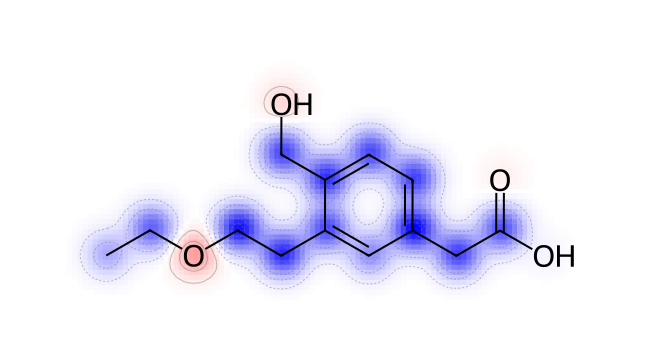

[REG] SimilarityMap (signed IG)
SMILES: CCOCCc1cc(CC(=O)O)ccc1CO


In [11]:
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import Draw
from IPython.display import SVG, display

rdDepictor.SetPreferCoordGen(True)                         # 优先使用较美观的 2D 坐标生成方式


# =========================
# 1. SMILES -> PyG Data
# =========================
def smiles_to_data_pyg(smiles, ref_dataset=None):
    """
    把一个 SMILES 转成 PyG 的 Data 对象。
    ref_dataset 用于校验当前分子的节点特征维度是否与训练数据一致。
    """
    data = None

    # 优先尝试 PyG 自带的 from_smiles
    try:
        from torch_geometric.utils.smiles import from_smiles
        data = from_smiles(smiles)                        # 通常会生成 x / edge_index / edge_attr
    except Exception:
        data = None

    # 如果没有 from_smiles，则用一个简化版 RDKit -> 图 的兜底写法
    if data is None:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"RDKit 解析 SMILES 失败: {smiles}")

        x_list = []
        for a in mol.GetAtoms():
            x_list.append([
                a.GetAtomicNum(),                         # 原子序数
                a.GetTotalDegree(),                       # 原子度
                a.GetFormalCharge(),                      # 形式电荷
                a.GetTotalNumHs(),                        # 氢原子数
                float(a.GetIsAromatic()),                 # 是否芳香
                float(a.IsInRing()),                      # 是否在环中
            ])
        x = torch.tensor(x_list, dtype=torch.float)      # 节点特征矩阵 [N, F]

        row, col = [], []
        for b in mol.GetBonds():
            i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
            row += [i, j]
            col += [j, i]                                 # 无向边转为双向有向边

        edge_index = torch.tensor([row, col], dtype=torch.long)

        data = Data(x=x, edge_index=edge_index)

    # 保证 x 是浮点类型
    if not torch.is_floating_point(data.x):
        data.x = data.x.float()

    data.smiles = smiles                                  # 保存原始 SMILES，便于后续可视化

    # 如果没有 batch 字段，则补一个单图 batch
    if not hasattr(data, "batch") or data.batch is None:
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long)

    # 特征维度校验：确保当前分子的 x 维度与训练数据一致
    if ref_dataset is not None:
        ref_dim = ref_dataset[0].x.size(-1)
        cur_dim = data.x.size(-1)
        if cur_dim != ref_dim:
            raise ValueError(
                f"当前 SMILES->Data 的 x 维度={cur_dim}，但训练数据 x 维度={ref_dim}。\n"
                f"请使用与你构建 ds_reg 完全一致的 featurizer。"
            )

    return data

# =========================
# 2. 手写 Integrated Gradients
# =========================
def integrated_gradients_x(model, data, steps=64, baseline=None):
    """
    对节点特征 x 计算 Integrated Gradients 归因。

    返回：
      attr : [N, F]
      表示每个节点、每个特征维度的归因值
    """
    model.eval()
    device = next(model.parameters()).device
    data = data.to(device)

    x0 = data.x
    if not torch.is_floating_point(x0):
        x0 = x0.float()
    x0 = x0.detach()

    # 默认 baseline 为全 0
    if baseline is None:
        baseline = torch.zeros_like(x0)
    baseline = baseline.to(device).type_as(x0)

    total_grad = torch.zeros_like(x0)                     # 累积梯度

    for i in range(1, steps + 1):
        a = float(i) / steps                              # 插值系数
        xi = baseline + a * (x0 - baseline)               # 当前插值点
        xi.requires_grad_(True)

        d_i = Data(
            x=xi,
            edge_index=data.edge_index,
            batch=data.batch,
            edge_attr=getattr(data, "edge_attr", None),
        )

        out = model(d_i)                                  # 前向传播

        # 当前版本按回归任务写：
        # 若模型返回的是 tuple/list（如 NIG），默认取第一个输出 mu
        if isinstance(out, (tuple, list)):
            score = out[0].view(-1)[0]
        else:
            score = out.view(-1)[0]

        model.zero_grad(set_to_none=True)
        if xi.grad is not None:
            xi.grad.zero_()

        score.backward()                                  # 对当前输出反向传播
        total_grad += xi.grad.detach()                    # 累积梯度

    avg_grad = total_grad / steps                         # 平均梯度
    attr = (x0 - baseline) * avg_grad                    # IG 公式
    return attr.detach()


# =========================
# 3. RDKit 热图可视化
# =========================
def show_similarity_map(mol, weights_signed, title="", cmap_name="bwr"):
    """
    用 RDKit SimilarityMaps 显示原子级热图。
    """
    w = np.asarray(weights_signed, dtype=float).reshape(-1)
    w = [float(x) for x in w.tolist()]                    # numpy -> Python list[float]

    d2d = Draw.MolDraw2DSVG(650, 360)
    d2d.drawOptions().useBWAtomPalette()                  # 使用黑白原子配色，便于突出热图

    SimilarityMaps.GetSimilarityMapFromWeights(
        mol, w, d2d,
        colorMap=cmap_name,                               # 常用 "bwr"：蓝-白-红
        alpha=0
    )

    d2d.FinishDrawing()
    display(SVG(d2d.GetDrawingText()))

    if title:
        print(title)


# =========================
# 4. 运行示例
# =========================
smi_in = "CCOCCc1cc(CC(=O)O)ccc1CO"                  # 待解释分子的 SMILES

# 4.1 SMILES -> Data
data = smiles_to_data_pyg(smi_in, ref_dataset=ds_reg).to(device)  # 用训练集 ds_reg 做特征维度校验

# 4.2 计算 IG 归因
attr_x = integrated_gradients_x(model_reg, data, steps=64)        # 节点特征级归因 [N, F]

# 4.3 聚合到原子级分数
node_signed = attr_x.sum(dim=1).detach().cpu().numpy()            # 保留符号的原子归因
node_abs    = attr_x.abs().sum(dim=1).detach().cpu().numpy()      # 绝对值原子归因

# 4.4 恢复分子并画图
mol = Chem.MolFromSmiles(smi_in)
assert mol.GetNumAtoms() == len(node_signed)                      # 原子数应与归因长度一致

show_similarity_map(
    mol,
    node_signed,
    title=f"[REG] SimilarityMap (signed IG)\nSMILES: {smi_in}"
)

## 9) 可解释性：Substructure Mask Explanation (SME)(ESOL任务)
**1. 先重新训练可支持mask掩盖的GNN模型。**

In [12]:
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader


# =========================
# 1. 数据集划分与加载
# =========================
ds_reg = MoleculeNet(root="./data", name="ESOL")                  # ESOL：水溶解度回归数据集

train_set, val_set, test_set = split_dataset(ds_reg, seed=42)    # 按固定随机种子划分 train / val / test

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)  # 训练集：小批量加载并打乱
val_loader   = DataLoader(val_set, batch_size=256)                 # 验证集：只做前向评估
test_loader  = DataLoader(test_set, batch_size=256)                # 测试集：只做最终评估


# =========================
# 2. 模型构建
# =========================
model_reg = GINMaskRegressor(                                     # 构建支持 pooling-mask 的 GIN 回归模型
    in_dim=ds_reg.num_features,                                   # 节点输入特征维度
    hidden_dim=64,                                                # 隐藏层维度
    num_layers=3,                                                 # GINConv 层数
    dropout=0.2                                                   # dropout 概率
).to(device)


# =========================
# 3. 优化器设置
# =========================
opt = torch.optim.Adam(
    model_reg.parameters(),                                       # 优化模型全部参数
    lr=1e-3,                                                      # 学习率
    weight_decay=1e-5                                             # L2 正则
)


# =========================
# 4. 训练过程
# =========================
best_val, best_state = 1e9, None                                  # 记录最优验证集 RMSE 及对应参数

for epoch in range(1, 101):                                        # 训练 50 个 epoch
    loss = train_one_epoch_regression(                            # 训练一个 epoch，返回平均训练损失
        model_reg, train_loader, opt, device
    )
    val_rmse, val_mae = eval_regression(                          # 在验证集上评估 RMSE 和 MAE
        model_reg, val_loader, device
    )

    if val_rmse < best_val:                                       # 若当前验证 RMSE 更小，则保存参数
        best_val = val_rmse
        best_state = {
            k: v.detach().cpu() for k, v in model_reg.state_dict().items()
        }

    if epoch % 10 == 0:                                            # 每 5 轮打印一次训练信息
        print(
            f"Epoch {epoch:03d} | "
            f"loss={loss:.4f} | "
            f"val_rmse={val_rmse:.4f} | "
            f"val_mae={val_mae:.4f}"
        )


# =========================
# 5. 恢复最佳模型
# =========================
if best_state is not None:
    model_reg.load_state_dict(best_state)                         # 恢复验证集表现最好的模型参数


# =========================
# 6. 测试集评估
# =========================
test_rmse, test_mae = eval_regression(model_reg, test_loader, device)  # 在测试集上评估最终性能

print("Best val_rmse =", best_val)
print("Test rmse     =", test_rmse)
print("Test mae      =", test_mae)

Epoch 010 | loss=1.4393 | val_rmse=2.2185 | val_mae=1.8537
Epoch 020 | loss=1.3304 | val_rmse=1.5911 | val_mae=1.1806
Epoch 030 | loss=0.9580 | val_rmse=1.0529 | val_mae=0.7941
Epoch 040 | loss=0.9776 | val_rmse=1.1265 | val_mae=0.9075
Epoch 050 | loss=1.2144 | val_rmse=1.2973 | val_mae=1.0186
Epoch 060 | loss=0.7615 | val_rmse=1.0316 | val_mae=0.8049
Epoch 070 | loss=0.9475 | val_rmse=1.3223 | val_mae=1.0277
Epoch 080 | loss=0.8657 | val_rmse=1.1513 | val_mae=0.9093
Epoch 090 | loss=0.7645 | val_rmse=0.8589 | val_mae=0.6799
Epoch 100 | loss=0.8143 | val_rmse=1.3076 | val_mae=0.9927
Best val_rmse = 0.7621734738349915
Test rmse     = 0.7053651809692383
Test mae      = 0.5076203346252441


**2. 通过SME解释刚构建的模型。**

SMILES: CCOCCc1cc(CC(=O)O)ccc1CO
Base prediction: -2.1329

Fragments and deltas:
01. atoms=[0, 1] | frag=CC | delta=-0.1188
02. atoms=[2] | frag=O | delta=0.0076
03. atoms=[3, 4] | frag=CC | delta=-0.2463
04. atoms=[5, 6, 7, 12, 13, 14] | frag=c1ccccc1 | delta=-1.5452
05. atoms=[8, 9, 10, 11] | frag=CC(=O)O | delta=0.1454
06. atoms=[15, 16] | frag=CO | delta=0.1623


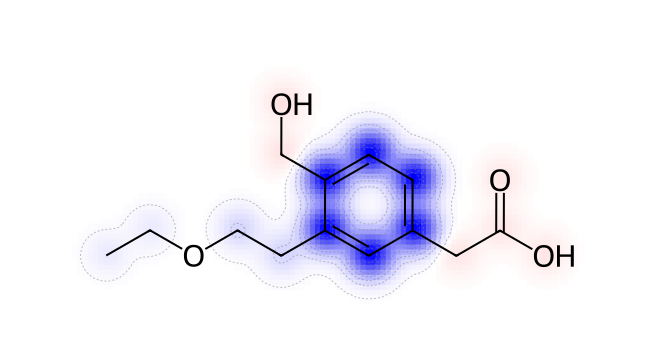

[REG | BRICS + pooling-mask]
SMILES: CCOCCc1cc(CC(=O)O)ccc1CO
Prediction: -2.1329


In [131]:
import numpy as np
import torch
from torch_geometric.data import Data

from rdkit import Chem
from rdkit.Chem import BRICS
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import SimilarityMaps
from rdkit.Chem import Draw
from IPython.display import SVG, display

rdDepictor.SetPreferCoordGen(True)                         # 优先使用较美观的 2D 坐标生成方式


# =========================
# 1. 基础工具
# =========================
def smiles_to_data_pyg(smiles, ref_dataset=None):
    data = None

    try:
        from torch_geometric.utils.smiles import from_smiles
        data = from_smiles(smiles)                         # 优先用 PyG 自带的 SMILES -> Data
    except Exception:
        data = None

    if data is None:                                       # 若没有 from_smiles，则用 RDKit 兜底构图
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            raise ValueError(f"RDKit 解析 SMILES 失败: {smiles}")

        x_list = []
        for a in mol.GetAtoms():
            x_list.append([
                a.GetAtomicNum(),                          # 原子序数
                a.GetTotalDegree(),                        # 原子度
                a.GetFormalCharge(),                       # 形式电荷
                a.GetTotalNumHs(),                         # 氢原子数
                float(a.GetIsAromatic()),                  # 是否芳香
                float(a.IsInRing()),                       # 是否在环中
            ])
        x = torch.tensor(x_list, dtype=torch.float)        # 节点特征矩阵 [N, F]

        row, col = [], []
        for b in mol.GetBonds():
            i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
            row += [i, j]
            col += [j, i]                                  # 无向边转为双向有向边

        edge_index = torch.tensor([row, col], dtype=torch.long)
        data = Data(x=x, edge_index=edge_index)

    if not torch.is_floating_point(data.x):
        data.x = data.x.float()                            # 保证节点特征是浮点类型

    data.smiles = smiles                                   # 保存原始 SMILES，便于后续可视化

    if not hasattr(data, "batch") or data.batch is None:
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long)  # 单图时补一个全 0 batch

    if ref_dataset is not None:
        ref_dim = ref_dataset[0].x.size(-1)
        cur_dim = data.x.size(-1)
        if cur_dim != ref_dim:                             # 检查当前分子的特征维度是否与训练集一致
            raise ValueError(
                f"当前 x 维度={cur_dim}，训练数据 x 维度={ref_dim}。\n"
                f"请使用与你构建 ds_reg 一致的 featurizer。"
            )

    return data


def data_to_mol(data):
    smi = data.smiles[0] if isinstance(data.smiles, (list, tuple)) else data.smiles  # 兼容 list / str
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        raise ValueError(f"RDKit 解析 SMILES 失败: {smi}")
    rdDepictor.Compute2DCoords(mol)                        # 生成 2D 坐标
    return mol, smi


def show_similarity_map(mol, weights, title="", cmap_name="bwr"):
    w = np.asarray(weights, dtype=float).reshape(-1)
    w = [float(x) for x in w.tolist()]                     # numpy -> Python list[float]

    d2d = Draw.MolDraw2DSVG(650, 360)
    d2d.drawOptions().useBWAtomPalette()                   # 原子用黑白配色，突出热图

    SimilarityMaps.GetSimilarityMapFromWeights(
        mol, w, d2d,
        colorMap=cmap_name,                                # 常用 "bwr"：蓝-白-红
        alpha=0
    )
    d2d.FinishDrawing()
    display(SVG(d2d.GetDrawingText()))

    if title:
        print(title)


def normalize_signed_scores(scores, eps=1e-12):
    scores = np.asarray(scores, dtype=float)
    max_abs = np.max(np.abs(scores))
    if max_abs < eps:
        return np.zeros_like(scores)                       # 避免全 0 时除 0
    return scores / max_abs                                # 归一化到 [-1, 1]


# =========================
# 2. BRICS 分片
# =========================
def brics_atom_fragments(mol):
    brics_bonds = list(BRICS.FindBRICSBonds(mol))          # 查找 BRICS 可切割键

    if len(brics_bonds) == 0:
        return [list(range(mol.GetNumAtoms()))]            # 若没有可切割键，则整个分子视作一个片段

    bond_indices = []
    for (a1, a2), _ in brics_bonds:
        bond = mol.GetBondBetweenAtoms(int(a1), int(a2))
        if bond is not None:
            bond_indices.append(bond.GetIdx())             # 收集需要切断的键索引

    if len(bond_indices) == 0:
        return [list(range(mol.GetNumAtoms()))]

    frag_mol = Chem.FragmentOnBonds(mol, bond_indices, addDummies=False)   # 按 BRICS 键切分
    frags = Chem.GetMolFrags(frag_mol, asMols=False, sanitizeFrags=False)  # 获取各片段原子索引

    return [list(frag) for frag in frags if len(frag) > 0]


def fragment_to_smiles(mol, atom_ids):
    atom_ids = sorted(set(int(i) for i in atom_ids))
    try:
        return Chem.MolFragmentToSmiles(mol, atomsToUse=atom_ids, canonical=True)  # 片段转 SMILES
    except Exception:
        return f"atoms={atom_ids}"                                 # 若失败则返回原子索引


# =========================
# 3. pooling-mask 回归解释
# =========================
def pooling_mask_explain_regression(model_reg, data, frag_atom_sets, normalize=True, verbose=True):
    """
    前提：
      model_reg 必须支持：
        - encode_nodes(data)
        - readout(h, batch, node_keep_mask=None)

    这里定义：
      delta = base_pred - masked_pred

    含义：
      delta > 0：mask 该片段后预测下降，说明该片段正向支持更高预测值
      delta < 0：mask 该片段后预测上升，说明该片段抑制预测值
    """
    model_reg.eval()
    device = next(model_reg.parameters()).device
    data = data.to(device)

    if not hasattr(data, "batch") or data.batch is None:
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)  # 单图时补 batch

    with torch.no_grad():
        h = model_reg.encode_nodes(data)                              # 先得到节点级 embedding
        base_pred = float(
            model_reg.readout(h, data.batch, node_keep_mask=None).view(-1)[0].item()
        )                                                             # 完整图预测值

        atom_scores = np.zeros(data.num_nodes, dtype=float)           # 原子级累计分数
        frag_deltas = []                                              # 每个片段的预测变化量

        for frag in frag_atom_sets:
            keep_mask = torch.ones(data.num_nodes, dtype=torch.float, device=device)
            keep_mask[frag] = 0.0                                     # 当前片段原子不参与 pooling

            masked_pred = float(
                model_reg.readout(h, data.batch, node_keep_mask=keep_mask).view(-1)[0].item()
            )                                                         # mask 后预测值

            delta = base_pred - masked_pred                           # 预测变化量
            frag_deltas.append(delta)

            for a in frag:
                atom_scores[a] += delta                               # 把片段分数累加到其包含的原子上

    frag_deltas = np.asarray(frag_deltas, dtype=float)
    atom_scores_norm = normalize_signed_scores(atom_scores) if normalize else atom_scores.copy()

    if verbose:
        print("Base prediction:", base_pred)
        print("Fragment deltas:", frag_deltas)

    return {
        "base_pred": base_pred,
        "frag_deltas": frag_deltas,
        "atom_scores_raw": atom_scores,
        "atom_scores_norm": atom_scores_norm,
    }


# =========================
# 4. 从 SMILES 直接解释
# =========================
def brics_pooling_mask_explain_from_smiles_reg(
    model_reg,
    smiles,
    ref_dataset=None,
    normalize=True,
    verbose=True,
):
    data = smiles_to_data_pyg(
        smiles, ref_dataset=ref_dataset
    ).to(next(model_reg.parameters()).device)              # SMILES -> Data

    mol, smi = data_to_mol(data)                           # Data -> RDKit Mol

    frag_atom_sets = brics_atom_fragments(mol)             # BRICS 分片
    frag_smiles = [fragment_to_smiles(mol, frag) for frag in frag_atom_sets]

    result = pooling_mask_explain_regression(              # 进行 pooling-mask 回归解释
        model_reg=model_reg,
        data=data,
        frag_atom_sets=frag_atom_sets,
        normalize=normalize,
        verbose=False,
    )

    if verbose:
        print(f"SMILES: {smi}")
        print(f"Base prediction: {result['base_pred']:.4f}")
        print("\nFragments and deltas:")
        for i, (frag, fsmi, delta) in enumerate(
            zip(frag_atom_sets, frag_smiles, result["frag_deltas"]), 1
        ):
            print(f"{i:02d}. atoms={frag} | frag={fsmi} | delta={delta:.4f}")

    result.update({
        "data": data,
        "mol": mol,
        "smiles": smi,
        "frag_atom_sets": frag_atom_sets,
        "frag_smiles": frag_smiles,
    })
    return result


# =========================
# 5. 运行示例
# =========================
smi_in = "CCOCCc1cc(CC(=O)O)ccc1CO"                   # 待解释分子的 SMILES

result = brics_pooling_mask_explain_from_smiles_reg(
    model_reg=model_reg,
    smiles=smi_in,
    ref_dataset=ds_reg,                                    # 用训练数据集校验特征维度
    normalize=True,
    verbose=True,
)

show_similarity_map(
    result["mol"],
    result["atom_scores_norm"],
    title=(
        f"[REG | BRICS + pooling-mask]\n"
        f"SMILES: {result['smiles']}\n"
        f"Prediction: {result['base_pred']:.4f}"
    ),
    cmap_name="bwr"
)